In [1]:
import pandas as pd

In [8]:
df = pd.read_csv('C:/Users/14/Desktop/Data Project/taobao-user-behavior-analysis/data/淘宝用户行为.csv')

In [30]:
df.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,total_spend
0,I138884,C241288,Female,28,Clothing,5,1500.40,Alipay,2022/8/5,NaN,NaN,NaN,NaN,NaN,7502.00
1,I317333,C111565,Male,21,Shoes,3,514.43,WeChat Pay,2021/12/12,NaN,NaN,NaN,NaN,NaN,1543.29
2,I127801,C266599,Male,20,Clothing,1,300.08,Card,2021/11/9,NaN,NaN,NaN,NaN,NaN,300.08
3,I173702,C988172,Female,66,Shoes,5,857.39,Alipay,2021/5/16,NaN,NaN,NaN,NaN,NaN,4286.95
4,I337046,C189076,Female,18,Books,4,60.60,Card,2021/10/24,NaN,NaN,NaN,NaN,NaN,242.40


In [31]:
df.shape

(99457, 15)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  object 
 1   customer_id     99457 non-null  object 
 2   gender          99457 non-null  object 
 3   age             99457 non-null  int64  
 4   category        99457 non-null  object 
 5   quantity        99457 non-null  int64  
 6   price           99457 non-null  float64
 7   payment_method  99457 non-null  object 
 8   invoice_date    99457 non-null  object 
 9   Unnamed: 9      0 non-null      float64
 10  Unnamed: 10     0 non-null      float64
 11  Unnamed: 11     0 non-null      float64
 12  Unnamed: 12     0 non-null      float64
 13  Unnamed: 13     1 non-null      float64
dtypes: float64(6), int64(2), object(6)
memory usage: 10.6+ MB


In [12]:
df.isnull().sum()

invoice_no            0
customer_id           0
gender                0
age                   0
category              0
quantity              0
price                 0
payment_method        0
invoice_date          0
Unnamed: 9        99457
Unnamed: 10       99457
Unnamed: 11       99457
Unnamed: 12       99457
Unnamed: 13       99456
dtype: int64

In [14]:
df.describe()

,age,quantity,price,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
count,99457.000000,99457.000000,99457.000000,0.0,0.0,0.0,0.0,1.0
mean,43.041938,3.003429,604.549295,NaN,NaN,NaN,NaN,3.5
std,14.962414,1.413025,807.096342,NaN,NaN,NaN,NaN,NaN
min,18.000000,1.000000,5.230000,NaN,NaN,NaN,NaN,3.5
25%,30.000000,2.000000,60.600000,NaN,NaN,NaN,NaN,3.5
50%,43.000000,3.000000,381.320000,NaN,NaN,NaN,NaN,3.5
75%,56.000000,4.000000,900.240000,NaN,NaN,NaN,NaN,3.5
max,69.000000,5.000000,5250.000000,NaN,NaN,NaN,NaN,3.5


<Axes: xlabel='age'>

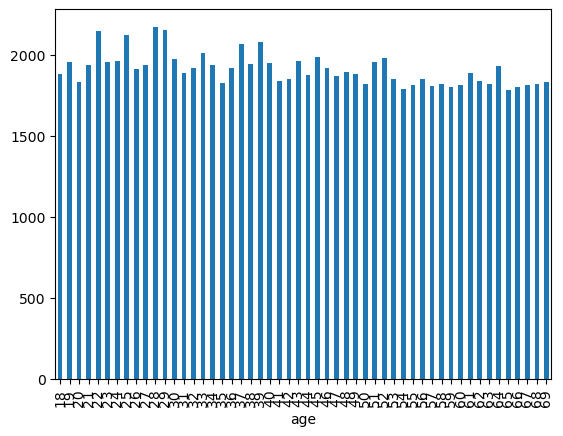

In [32]:
#用户画像
df['age'].value_counts().sort_index().plot(kind='bar')

In [33]:
#商品类别
df['category'].value_counts().head(10)

category
Clothing           30771
Food & Beverage    15865
Cosmetics          15097
Toys               10087
Shoes              10034
Technology          7623
Souvenir            4999
Books               4981
Name: count, dtype: int64

In [34]:
#消费
total_quantity = df['quantity'].sum()
print(total_quantity)
df.groupby('category')['quantity'].sum().sort_values(ascending=False)

298712


category
Clothing           92389
Food & Beverage    47547
Cosmetics          45465
Toys               30321
Shoes              30217
Technology         22920
Books              14982
Souvenir           14871
Name: quantity, dtype: int64

In [21]:
df['total_spend'] = df['quantity'] * df['price']
df['total_spend'].sum()

np.float64(217607148.73213032)

In [24]:
#每个用户消费总额
df.groupby('customer_id')['total_spend'].sum().sort_values(ascending=False)

customer_id
C142723    26250.00
C273314    26250.00
C109455    26250.00
C272918    26250.00
C666317    26250.00
             ...   
C144669        5.23
C200251        5.23
C119721        5.23
C160158        5.23
C313920        5.23
Name: total_spend, Length: 99457, dtype: float64

<Axes: xlabel='age'>

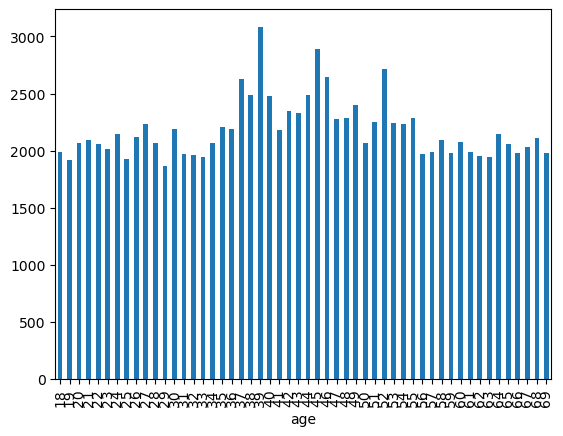

In [25]:
#年龄 vs 消费能力
df.groupby('age')['total_spend'].mean().plot(kind='bar')

In [26]:
#类别 vs 年龄
pd.crosstab(df['age'], df['category'])

category,Books,Clothing,Cosmetics,Food & Beverage,Shoes,Souvenir,Technology,Toys
age,,,,,,,,
18,134,576,270,309,167,109,138,179
19,112,616,292,322,203,91,121,202
20,89,579,269,307,195,83,118,196
21,88,594,289,312,195,103,132,224
22,125,661,337,348,181,117,154,225
23,107,547,290,346,199,97,142,226
24,108,617,268,323,198,103,149,197
25,136,578,347,381,181,133,150,219
26,88,594,290,307,197,113,132,191
